In [76]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from pmdarima import auto_arima, ARIMA, model_selection
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error, mean_absolute_percentage_error, r2_score

In [77]:
df= pd.read_csv(r"C:\Users\MINE\Desktop\bitcoin prediction\BTC_USD Bitfinex Historical Data (1).csv")

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      4058 non-null   object
 1   Price     4058 non-null   object
 2   Open      4058 non-null   object
 3   High      4058 non-null   object
 4   Low       4058 non-null   object
 5   Vol.      4048 non-null   object
 6   Change %  4058 non-null   object
dtypes: object(7)
memory usage: 222.1+ KB


In [79]:
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,02/11/2026,"67,023.0","68,873.0","69,352.0","66,644.0",2.11K,-2.69%
1,02/10/2026,"68,873.0","70,166.0","70,541.0","67,975.0",1.89K,-1.84%
2,02/09/2026,"70,166.0","70,381.0","71,494.0","68,400.0",2.63K,-0.31%
3,02/08/2026,"70,381.0","69,389.0","72,255.0","68,966.0",1.50K,1.43%
4,02/07/2026,"69,389.0","70,639.0","71,668.0","67,465.0",1.96K,-1.76%


In [80]:
df.head(10)

,Date,Price,Open,High,Low,Vol.,Change %
0,02/11/2026,"67,023.0","68,873.0","69,352.0","66,644.0",2.11K,-2.69%
1,02/10/2026,"68,873.0","70,166.0","70,541.0","67,975.0",1.89K,-1.84%
2,02/09/2026,"70,166.0","70,381.0","71,494.0","68,400.0",2.63K,-0.31%
3,02/08/2026,"70,381.0","69,389.0","72,255.0","68,966.0",1.50K,1.43%
4,02/07/2026,"69,389.0","70,639.0","71,668.0","67,465.0",1.96K,-1.76%
5,02/06/2026,"70,634.0","62,995.0","71,800.0","60,246.0",3.54K,12.22%
6,02/05/2026,"62,940.0","73,280.0","73,426.0","62,590.0",4.25K,-14.11%
7,02/04/2026,"73,280.0","75,892.0","77,054.0","72,149.0",3.00K,-3.44%
8,02/03/2026,"75,892.0","78,848.0","79,276.0","73,104.0",2.49K,-3.75%
9,02/02/2026,"78,848.0","77,030.0","79,397.0","75,090.0",4.28K,2.38%


In [81]:
df.set_index('Date', inplace=True)

In [82]:
df.index = pd.to_datetime(df.index)

In [83]:
col= ['Price', 'Open', 'High', 'Low']
for col in col:
  df[col]= df[col].str.replace(',','').astype('float64')

In [84]:
df= df.asfreq('B')

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2900 entries, 2015-01-01 to 2026-02-11
Freq: B
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     2899 non-null   float64
 1   Open      2899 non-null   float64
 2   High      2899 non-null   float64
 3   Low       2899 non-null   float64
 4   Vol.      2891 non-null   object 
 5   Change %  2899 non-null   object 
dtypes: float64(4), object(2)
memory usage: 158.6+ KB


In [86]:
df.isnull().sum()

Price       1
Open        1
High        1
Low         1
Vol.        9
Change %    1
dtype: int64

In [87]:
df.dropna(inplace=True)

In [88]:
df.duplicated().sum()

0

# Exploratory Data Analysis 

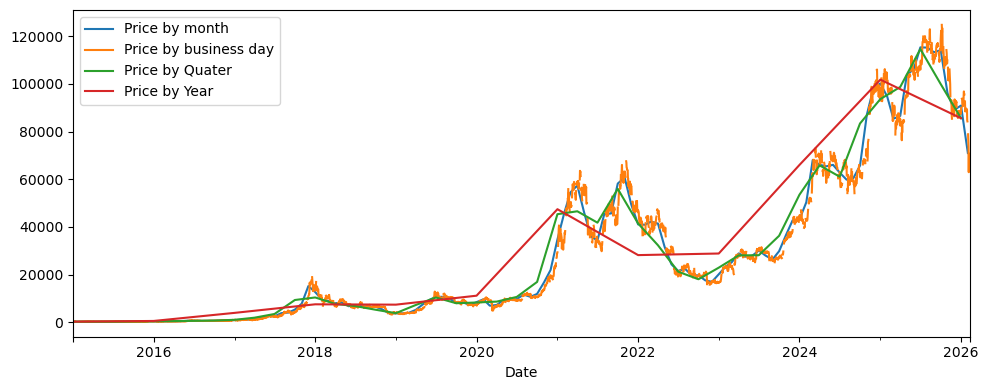

In [89]:
plt.figure(figsize=(10,4))

df.Price.resample('ME').mean().plot(label= 'Price by month')

df.Price.resample('D').mean().plot(label= 'Price by business day')

df.Price.resample('QE').mean().plot(label= 'Price by Quater')

df.Price.resample('YE').mean().plot(label= 'Price by Year')

plt.tight_layout()
plt.legend()
plt.show()

In [90]:
df.rename(columns={"Price" :"Y"}, inplace= True)

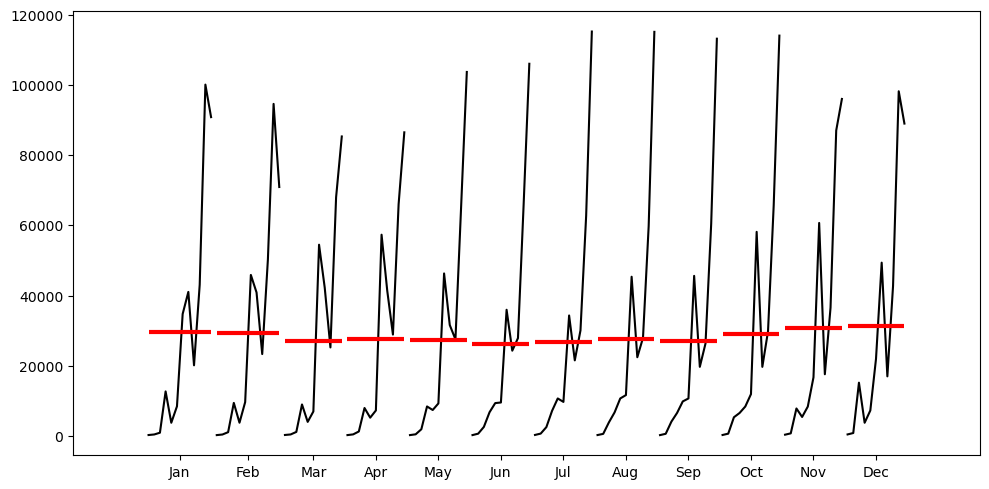

In [91]:
month_plot(df.Y.resample('ME').mean()).set_size_inches(10,5)

plt.tight_layout()
plt.show()

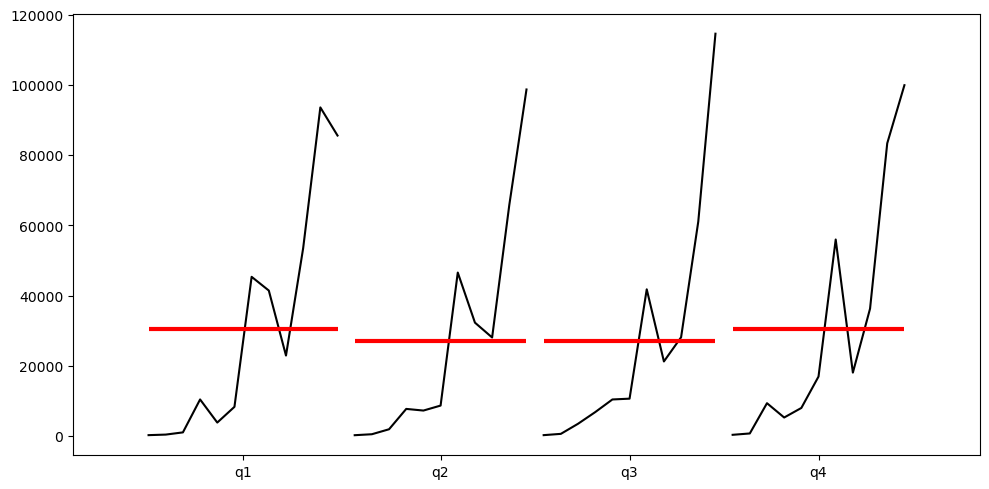

In [92]:
quarter_plot(df.Y.resample('QE').mean()).set_size_inches(10,5)

plt.tight_layout()
plt.show()

In [93]:
df.Y.isnull().sum()

0

In [94]:
df.isnull().sum()

Y           0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64

In [95]:
decompose= seasonal_decompose(df.Y, 
                              model= 'mul', 
                              period= 365)

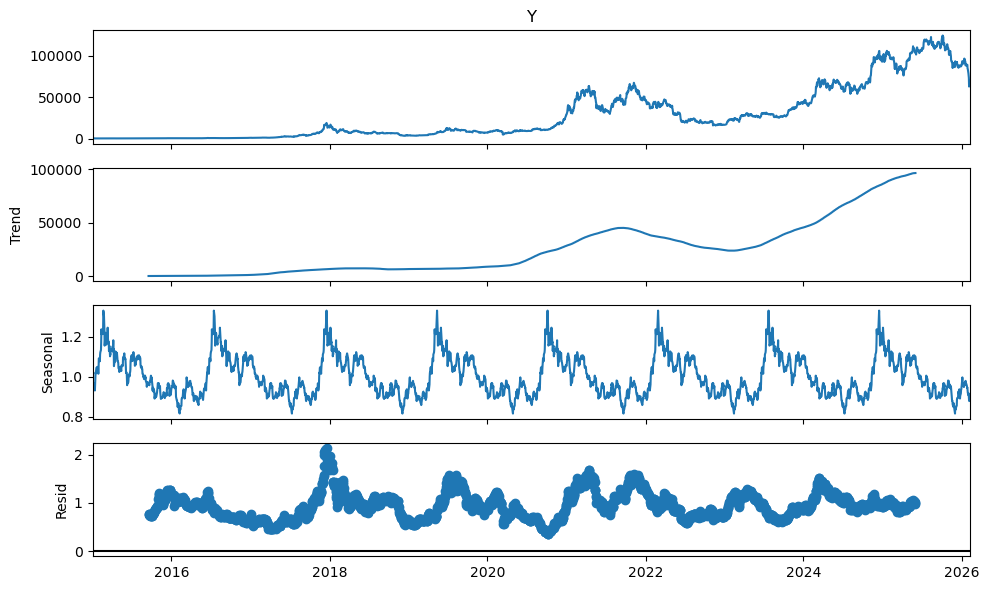

In [96]:
decompose.plot().set_size_inches(10,6)

plt.tight_layout()
plt.show()

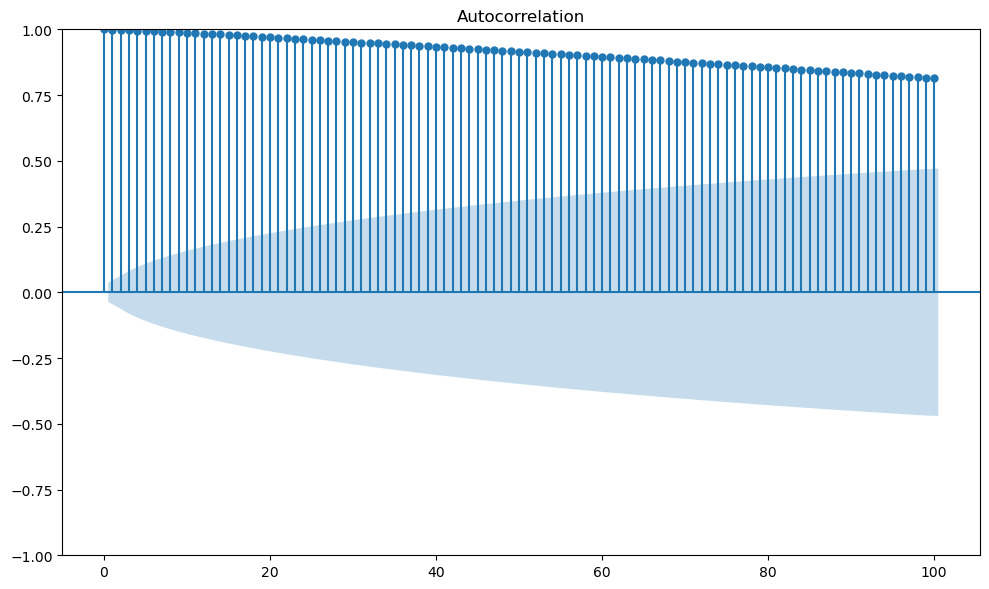

In [97]:
plot_acf(df.Y, lags=100).set_size_inches(10,6)

plt.tight_layout()
plt.show()

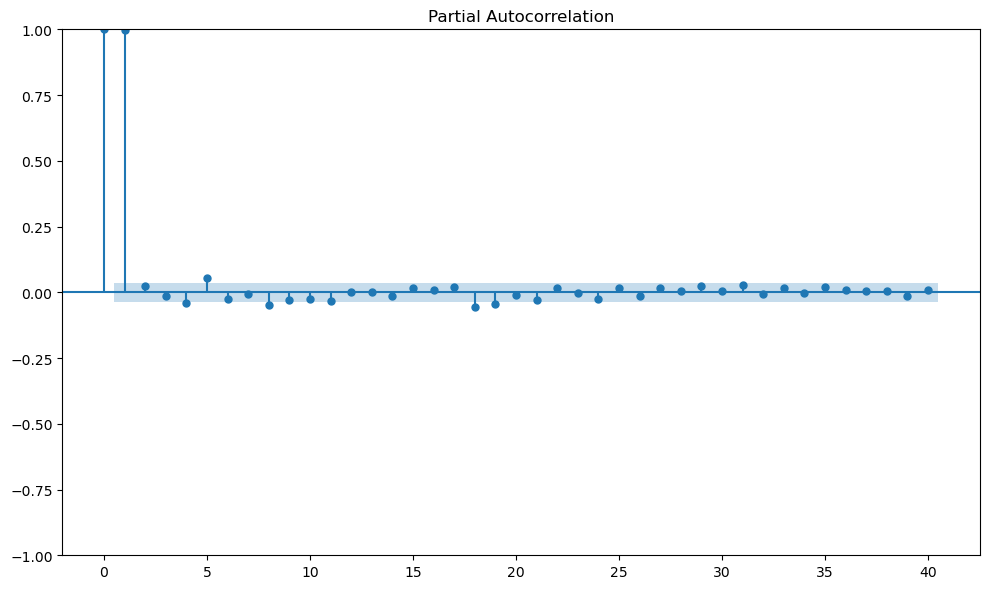

In [98]:
plot_pacf(df.Y, lags=40,  
    alpha=0.05,  
    method='ywm',  
    use_vlines=True,  
    title='Partial Autocorrelation',  
    zero=True,  
    ).set_size_inches(10,6)
plt.tight_layout()
plt.show()

# Splitting Data

In [99]:
df.head()

,Y,Open,High,Low,Vol.,Change %
Date,,,,,,
2015-01-01,313.9,317.5,317.5,312.9,0.93K,-0.99%
2015-01-02,315.1,313.6,316.0,313.0,1.32K,0.40%
2015-01-05,273.2,261.0,276.5,260.5,2.68K,5.57%
2015-01-06,285.4,273.2,287.8,268.5,6.86K,4.46%
2015-01-07,297.0,286.1,303.8,285.0,1.53K,4.07%


In [100]:
df.isnull().sum()

Y           0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64

In [101]:
df.duplicated().sum()

0

In [102]:
df.sort_index(inplace=True, ascending=False)

In [103]:
df.head()

,Y,Open,High,Low,Vol.,Change %
Date,,,,,,
2026-02-11,67023.0,68873.0,69352.0,66644.0,2.11K,-2.69%
2026-02-10,68873.0,70166.0,70541.0,67975.0,1.89K,-1.84%
2026-02-09,70166.0,70381.0,71494.0,68400.0,2.63K,-0.31%
2026-02-06,70634.0,62995.0,71800.0,60246.0,3.54K,12.22%
2026-02-05,62940.0,73280.0,73426.0,62590.0,4.25K,-14.11%


In [104]:
print(df.index)
print(df.index.freq)
print(pd.infer_freq(df.index))

DatetimeIndex(['2026-02-11', '2026-02-10', '2026-02-09', '2026-02-06',
               '2026-02-05', '2026-02-04', '2026-02-03', '2026-02-02',
               '2026-01-30', '2026-01-29',
               ...
               '2015-01-14', '2015-01-13', '2015-01-12', '2015-01-09',
               '2015-01-08', '2015-01-07', '2015-01-06', '2015-01-05',
               '2015-01-02', '2015-01-01'],
              dtype='datetime64[ns]', name='Date', length=2891, freq=None)
None
None


In [122]:
df = df.asfreq('B') 

In [123]:
df.sort_index(inplace= True)

In [124]:
df.index

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-05', '2015-01-06',
               '2015-01-07', '2015-01-08', '2015-01-09', '2015-01-12',
               '2015-01-13', '2015-01-14',
               ...
               '2026-01-29', '2026-01-30', '2026-02-02', '2026-02-03',
               '2026-02-04', '2026-02-05', '2026-02-06', '2026-02-09',
               '2026-02-10', '2026-02-11'],
              dtype='datetime64[ns]', name='Date', length=2900, freq='B')

In [125]:
# df.sort_index(inplace=True, ascending=False)

In [126]:
test_days = 30 # Number of days to reserve for testing
train, test = df.iloc[:-test_days], df.iloc[-test_days:]

In [127]:
train.shape

(2870, 6)

In [128]:
test.shape

(30, 6)

In [129]:
train.head()

,Y,Open,High,Low,Vol.,Change %
Date,,,,,,
2015-01-01,313.9,317.5,317.5,312.9,0.93K,-0.99%
2015-01-02,315.1,313.6,316.0,313.0,1.32K,0.40%
2015-01-05,273.2,261.0,276.5,260.5,2.68K,5.57%
2015-01-06,285.4,273.2,287.8,268.5,6.86K,4.46%
2015-01-07,297.0,286.1,303.8,285.0,1.53K,4.07%


In [130]:
test.head()

,Y,Open,High,Low,Vol.,Change %
Date,,,,,,
2026-01-01,88876.0,87720.0,88944.0,87593.0,0.30K,1.33%
2026-01-02,89993.0,88876.0,90942.0,88442.0,1.05K,1.26%
2026-01-05,93744.0,91483.0,94615.0,91423.0,1.46K,2.49%
2026-01-06,93612.0,93744.0,94280.0,91233.0,1.84K,-0.14%
2026-01-07,91349.0,93612.0,93612.0,90651.0,1.05K,-2.42%


# Exponential Smoothening

In [131]:
model= SimpleExpSmoothing(train.Y.ffill()).fit()

In [168]:
model.summary()

Dep. Variable:,Y,No. Observations:,2870
Model:,SimpleExpSmoothing,SSE,4913258852.653
Optimized:,True,AIC,41197.500
Trend:,None,BIC,41209.424
Seasonal:,None,AICC,41197.514
Seasonal Periods:,None,Date:,"Mon, 23 Feb 2026"
Box-Cox:,False,Time:,22:57:23
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.9511977,alpha,True
initial_level,313.90000,l.0,False


In [132]:
print(model.mle_retvals)

  message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
  success: True
   status: 0
      fun: 4913258852.652913
        x: [ 9.512e-01]
      nit: 2
      jac: [ 2.861e+02]
     nfev: 8
     njev: 4
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>


In [133]:
forecast= model.forecast(len(test))

In [134]:
forecast.head()

2026-01-01    87749.131139
2026-01-02    87749.131139
2026-01-05    87749.131139
2026-01-06    87749.131139
2026-01-07    87749.131139
Freq: B, dtype: float64

In [135]:
# Model assesment
def model_evaluator(test, train, prediction, chart_title):
    plt.figure(figsize=(10,4))
    plt.plot(train, label= 'Train')
    plt.plot(test, label= 'Test')
    plt.plot(prediction, label= 'Predictions', color='green')

    plt.legend()
    plt.title(f"Train Test And Predictions With {chart_title}")
    plt.tight_layout()
    plt.show()
    print(f'the mean absolute error is {mean_absolute_error(test,prediction)}')
    print(f'the mean absolute percentage is { 100 * (mean_absolute_percentage_error(test, prediction))} %')
    print(f'The root mean squared error is { root_mean_squared_error(test, prediction)}')
    print(f'the r2_score is {r2_score(test, prediction)}')

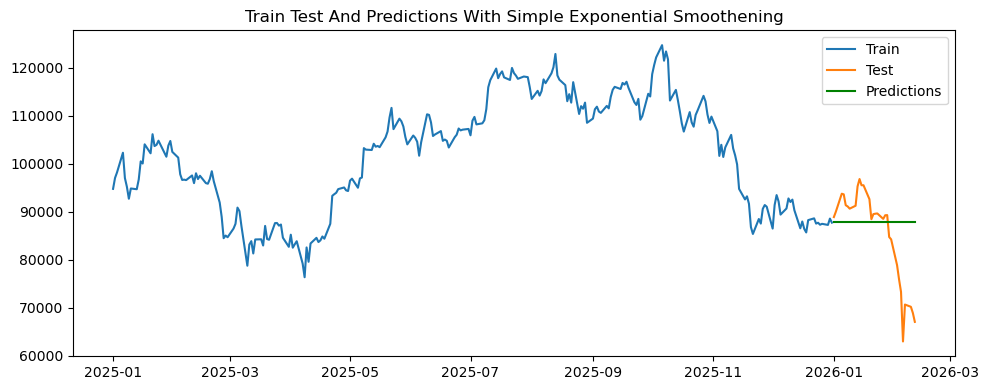

the mean absolute error is 7210.156286974746
the mean absolute percentage is 9.411197817693669 %
The root mean squared error is 9787.26483121959
the r2_score is -0.052316472501624744


In [147]:
model_evaluator(test.Y,train.Y.loc['2025'],forecast,'Simple Exponential Smoothening')

In [243]:
# Double exponential smoothening
double_smoothening= ExponentialSmoothing(train.Y.ffill(),
                                          trend= 'add',
                                          seasonal= None,
                                          seasonal_periods= 300).fit()

In [244]:
double_smoothening.summary()

Dep. Variable:,Y,No. Observations:,2870
Model:,ExponentialSmoothing,SSE,4910314440.423
Optimized:,True,AIC,41199.780
Trend:,Additive,BIC,41223.628
Seasonal:,None,AICC,41199.809
Seasonal Periods:,None,Date:,"Mon, 23 Feb 2026"
Box-Cox:,False,Time:,23:11:45
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.9505777,alpha,True
smoothing_trend,0.000000,beta,True


In [245]:
double_forecast= double_smoothening.forecast(len(test))

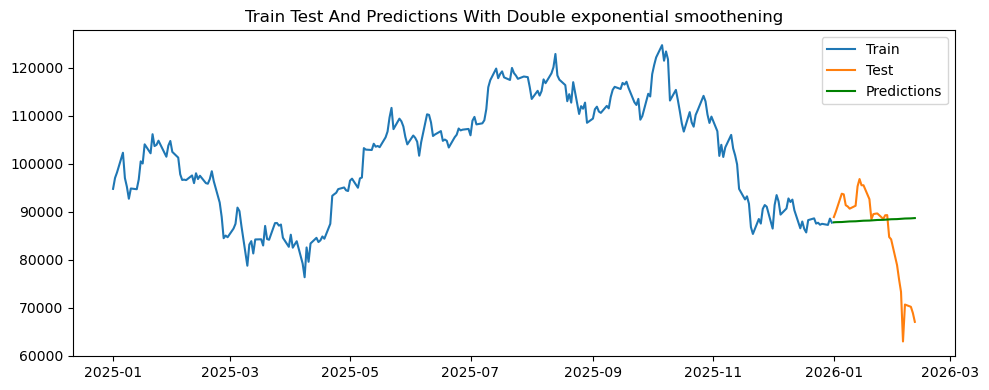

the mean absolute error is 7255.168574761225
the mean absolute percentage is 9.533907286912319 %
The root mean squared error is 10114.510290814038
the r2_score is -0.12386309438011289


In [246]:
model_evaluator(test.Y, train.Y.loc['2025'], double_forecast, 'Double exponential smoothening')

In [262]:
thripple_exponential= ExponentialSmoothing(train.Y.ffill(),
                                            seasonal= 'mul',
                                            trend= 'mul',
                                            seasonal_periods= 300,
                                            initialization_method="estimated" 
                                            ).fit()

C:\Users\MINE\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [263]:
# thripple_exponential.summary()

In [264]:
thriple_forecast= thripple_exponential.forecast(len(test))

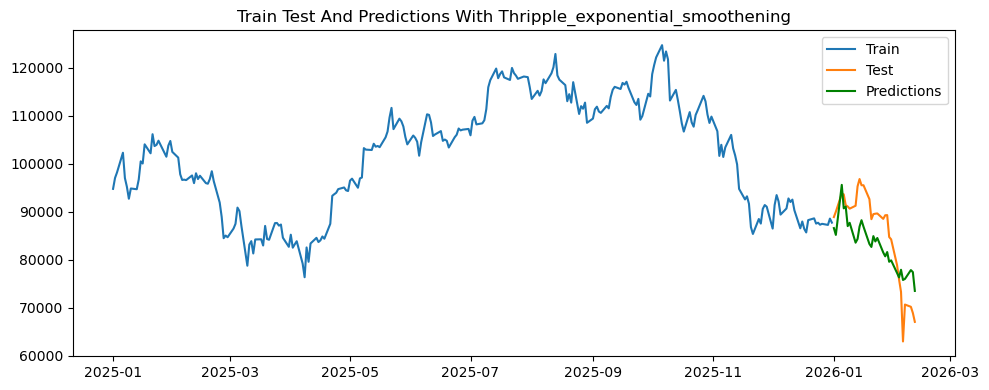

the mean absolute error is 5821.510572588859
the mean absolute percentage is 6.970559672943498 %
The root mean squared error is 6559.448793247404
the r2_score is 0.5273296276657484


In [265]:
model_evaluator(test.Y, train.Y.loc['2025'], thriple_forecast, 'Thripple_exponential_smoothening')

# Arima, Sarima,Sarimax

In [ ]:
arima= auto_arima(train.Y,
                    )